#### PARTIE 1 - IMPORTS ET CHARGEMENT DES DONNÉES


In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
# Charger les datasets prétraités
train_df = pd.read_csv("../data/processed/train_preprocessed.csv")
test_df = pd.read_csv("../data/processed/test_preprocessed.csv")

# Charger les embeddings
X = np.load("../data/processed/train_embeddings.npy")
X_test = np.load("../data/processed/test_embeddings.npy")

In [3]:
# Labels
y = train_df["category"]
y_test = test_df["category"]

print("Taille de X :", X.shape)
print("Taille de y :", y.shape)
print("Nombre d'intentions uniques :", y.nunique())

Taille de X : (14399, 384)
Taille de y : (14399,)
Nombre d'intentions uniques : 77


#### PARTIE 2 - ENCODAGE DES LABELS

In [4]:
le = LabelEncoder() 
y_encoded = le.fit_transform(y)
y_test_encoded = le.transform(y_test)
print("Nombre de classes :", len(le.classes_)) 
print("Exemple d'encodage :", list(zip(le.classes_[:5], y_encoded[:5])))

Nombre de classes : 77
Exemple d'encodage : [('Refund_not_showing_up', np.int64(12)), ('activate_my_card', np.int64(12)), ('age_limit', np.int64(12)), ('apple_pay_or_google_pay', np.int64(12)), ('atm_support', np.int64(12))]


#### PARTIE 3 - ENTRAÎNEMENT DU MODÈLE SVM AVEC GRID SEARCH


In [6]:
# param_grid = {
#     'kernel': ['linear', 'rbf'],
#     'C': [0.5, 1, 2],
#     'gamma': ['scale', 'auto']
# }

# print("\n Recherche des meilleurs hyperparamètres...")
# grid = GridSearchCV(
#     SVC(probability=True, random_state=42),
#     param_grid,
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )
# grid.fit(X, y_encoded)

# svm_model = grid.best_estimator_
# print("Meilleurs paramètres trouvés :", grid.best_params_)
print("\n🔧 Entraînement du modèle SVM...")
svm_model = SVC(
    kernel='rbf',           # Noyau radial
    C=1.0,                  # Paramètre de régularisation
    gamma='scale',          # Paramètre gamma
    probability=True,       # Activer les probabilités
    random_state=42         # Reproductibilité
)

# Entraînement direct
svm_model.fit(X, y_encoded)

print("✅ Modèle SVM entraîné avec succès!")
print(f"Paramètres utilisés : kernel=rbf, C=1.0, gamma=scale")


🔧 Entraînement du modèle SVM...
✅ Modèle SVM entraîné avec succès!
Paramètres utilisés : kernel=rbf, C=1.0, gamma=scale


#### PARTIE 4 - SAUVEGARDE DU MODÈLE ET DE L'ENCODEUR


In [ ]:
os.makedirs("../models", exist_ok=True)
joblib.dump(svm_model, "../models/intent_svm.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
print("Modèle et encodeur sauvegardés dans '../models/'")

In [8]:
# Prédiction SVM
y_test_pred = svm_model.predict(X_test)

# Calcul des métriques
acc_test = accuracy_score(y_test_encoded, y_test_pred)
f1_macro_test = f1_score(y_test_encoded, y_test_pred, average='macro')
f1_weighted_test = f1_score(y_test_encoded, y_test_pred, average='weighted')

print("\nÉvaluation finale sur le test :")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1-score (macro) : {f1_macro_test:.4f}")
print(f"F1-score (pondéré) : {f1_weighted_test:.4f}")


Évaluation finale sur le test :
Accuracy : 0.8682
F1-score (macro) : 0.8687
F1-score (pondéré) : 0.8687


#### PARTIE 5 - ÉVALUATION SUR LE JEU DE TEST


In [9]:
print("\nClassification Report :")
print(classification_report(y_test_encoded, y_test_pred, target_names=le.classes_))


Classification Report :
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.88      0.95      0.92        40
                                activate_my_card       0.95      0.95      0.95        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.98      1.00      0.99        40
                                automatic_top_up       0.97      0.90      0.94        40
         balance_not_updated_after_bank_transfer       0.64      0.70      0.67        40
balance_not_updated_after_cheque_or_cash_deposit       0.79      0.93      0.85        40
                         beneficiary_not_allowed       0.85      0.88      0.86        40
                                 cancel_transfer       0.97      0.95     

In [13]:
# --- Identifier les erreurs ---
errors_idx = np.where(y_test_pred != y_test_encoded)[0]

# --- Créer un DataFrame des erreurs ---
errors_df = pd.DataFrame({
    "text": test_df.iloc[errors_idx]["clean_text"].values,  # Assurez-vous que la colonne existe
    "true_label": le.inverse_transform(y_test_encoded[errors_idx]),
    "predicted_label": le.inverse_transform(y_test_pred[errors_idx])
})

print("\nExemples d'erreurs de classification sur le jeu de test :", errors_df.shape)
errors_df.head()




Exemples d'erreurs de classification sur le jeu de test : (406, 3)


,text,true_label,predicted_label
0,locate card,card_arrival,lost_or_stolen_card
1,card arrive,card_arrival,card_delivery_estimate
2,card,card_arrival,getting_spare_card
3,receive card,card_arrival,order_physical_card
4,long card delivery,card_arrival,card_delivery_estimate


#### PARTIE 6 - MATRICE DE CONFUSION

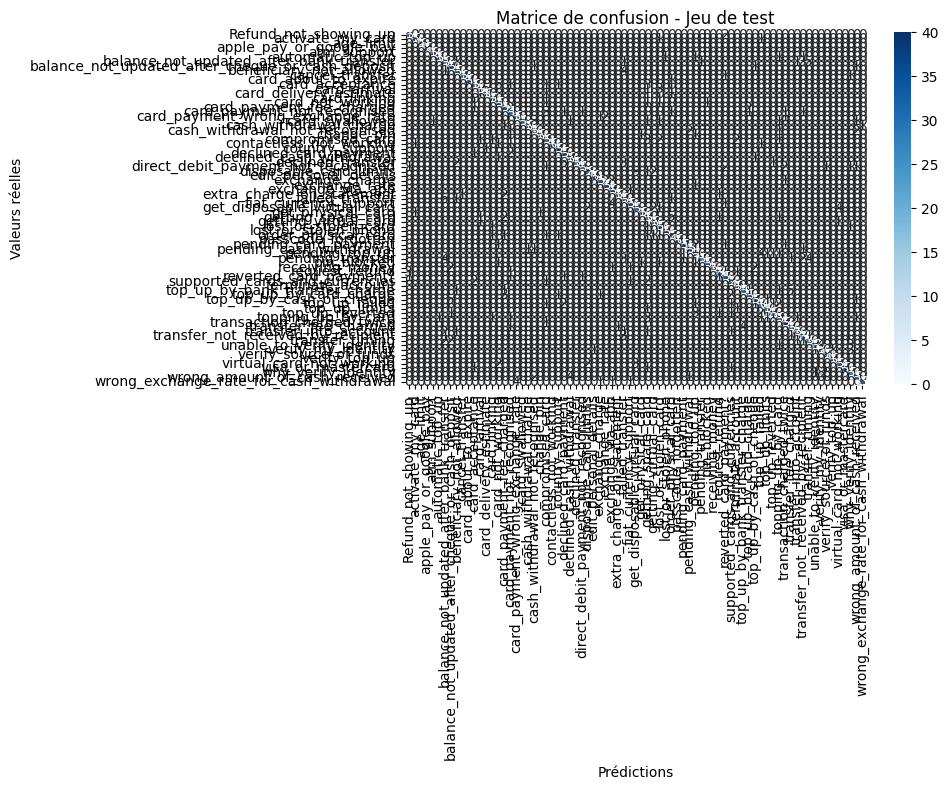

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_test_encoded, y_test_pred),
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues", annot=True,
    fmt='d'
)
plt.title("Matrice de confusion - Jeu de test")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()